In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as scp
from scipy.optimize import brentq
import Black_Scholes as BS

## Loading the NSE option chain

The raw NSE CSV has a **two-line header** — a `CALLS , , PUTS` banner, then the real column names — and the labels `LTP`, `IV`, `OI`, `VOLUME` each appear **twice**: once for the call side (left of `STRIKE`) and once for the put side (right of it). That is why `df['CALLS']['LTP']` fails — after a plain `read_csv` there is no clean `LTP` column.

So we skip the two header lines, assign our own positional column names, and strip the thousands-commas and the `-` placeholders before converting everything to numbers.

In [36]:
# our own names for the 23 columns (a blank one sits at each end of every NSE row)
cols = ['blank_l',
        'C_OI','C_CHNG_OI','C_VOLUME','C_IV','C_LTP','C_CHNG','C_BIDQTY','C_BID','C_ASK','C_ASKQTY',
        'STRIKE',
        'P_BIDQTY','P_BID','P_ASK','P_ASKQTY','P_CHNG','P_LTP','P_IV','P_VOLUME','P_CHNG_OI','P_OI',
        'blank_r']

df = pd.read_csv('option-chain-ED-NIFTY-25-Aug-2026.csv', skiprows=2, header=None, names=cols)
df = df.drop(columns=['blank_l', 'blank_r'])

def to_num(s):
    # '3,100.00' -> 3100.0 ,  '-' -> NaN
    return pd.to_numeric(
        s.astype(str).str.replace(',', '', regex=False).str.strip().replace('-', np.nan),
        errors='coerce')

optionChain = df.apply(to_num)
optionChain.head()

,C_OI,C_CHNG_OI,C_VOLUME,C_IV,C_LTP,C_CHNG,C_BIDQTY,C_BID,C_ASK,C_ASKQTY,...,P_BIDQTY,P_BID,P_ASK,P_ASKQTY,P_CHNG,P_LTP,P_IV,P_VOLUME,P_CHNG_OI,P_OI
0,116.0,-8.0,10.0,72.18,3100.00,-20.80,65,3042.15,3101.30,130,...,24050,0.40,0.45,40495,-0.3,0.45,43.71,49395.0,-2774.0,42036.0
1,1.0,NaN,NaN,60.38,2971.00,NaN,130,2983.45,3097.65,780,...,13975,0.40,0.50,260,-0.3,0.50,43.41,4528.0,872.0,2421.0
2,57.0,NaN,NaN,NaN,3070.00,NaN,65,2723.95,3046.10,780,...,44525,0.40,0.45,2600,-0.3,0.40,41.88,15213.0,50.0,13173.0
3,NaN,NaN,NaN,NaN,NaN,NaN,780,2701.65,2997.75,780,...,1495,0.50,0.60,910,-0.2,0.60,42.71,717.0,77.0,902.0
4,1.0,-1.0,2.0,83.24,2940.75,324.45,65,2819.55,2946.55,780,...,16185,0.45,0.55,24895,-0.3,0.45,40.92,14031.0,-3.0,9238.0


## Separating strike and LTP

`STRIKE` is the shared middle column; the last traded price lives in `C_LTP` for calls and `P_LTP` for puts. We pull each side into its own tidy frame (dropping strikes that never traded, i.e. `LTP` is blank), using `MarketPrice` / `StrikePrice` so the rest of the notebook can price against them.

In [37]:
calls = (pd.DataFrame({'StrikePrice': optionChain['STRIKE'], 'MarketPrice': (optionChain['C_BID'] + optionChain['C_ASK']) / 2, 'IV': optionChain['C_IV']})
           .dropna(subset=['MarketPrice']).reset_index(drop=True))
puts  = (pd.DataFrame({'StrikePrice': optionChain['STRIKE'], 'MarketPrice': (optionChain['P_BID'] + optionChain['P_ASK']) / 2, 'IV': optionChain['P_IV']})
           .dropna(subset=['MarketPrice']).reset_index(drop=True))

print(f'{len(calls)} call strikes, {len(puts)} put strikes')
calls.head()

121 call strikes, 121 put strikes


,StrikePrice,MarketPrice,IV
0,21200.0,3071.725,72.18
1,21250.0,3040.550,60.38
2,21300.0,2885.025,NaN
3,21350.0,2849.700,NaN
4,21400.0,2883.050,83.24


## The volatility smile

With strike and IV separated we can plot the smile directly from the exchange's IV column. Deep in-the-money options are illiquid and their quoted IVs are unreliable, so the clean way to draw the smile is to use **out-of-the-money** options on each side: puts below spot, calls above it.

> The spot below is inferred from put-call parity around the at-the-money strike (where call LTP ≈ put LTP). Replace it with the actual underlying level from your snapshot for a precise plot.

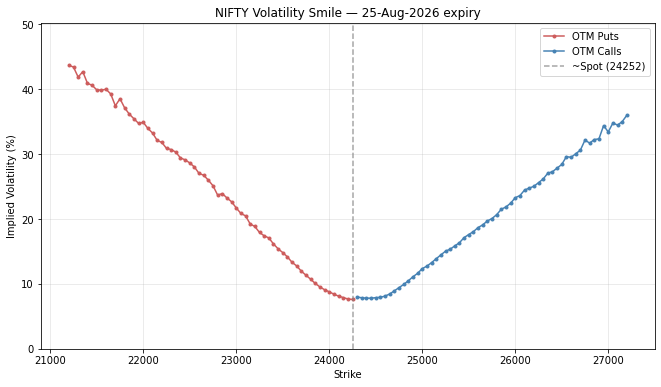

In [38]:
spot = 24252

otm_calls = calls[calls['StrikePrice'] >= spot]
otm_puts  = puts[puts['StrikePrice']  <= spot]

plt.figure(figsize=(11, 6))
plt.plot(otm_puts['StrikePrice'].to_numpy(),  otm_puts['IV'].to_numpy(),  'o-', ms=3, color='indianred', label='OTM Puts')
plt.plot(otm_calls['StrikePrice'].to_numpy(), otm_calls['IV'].to_numpy(), 'o-', ms=3, color='steelblue', label='OTM Calls')
plt.axvline(spot, ls='--', color='gray', alpha=.7, label=f'~Spot ({spot})')
plt.title('NIFTY Volatility Smile — 25-Aug-2026 expiry')
plt.xlabel('Strike'); plt.ylabel('Implied Volatility (%)')
plt.ylim(0, max(otm_puts['IV'].max(), otm_calls['IV'].max()) * 1.15)
plt.legend(); plt.grid(alpha=.3); plt.show()

In [39]:
def find_iv(mkt, S, K, r, T):
    f = lambda sig: BS.calculateCallOptionPrice(S, K, r, T, sig) - mkt
    
    try:
        return brentq(f, 0.001, 3.0) * 100
    except ValueError:      # no root in [0.1%, 300%] vol → return NaN instead of crashing
        return np.nan

In [40]:
r = 0.065
T = 2 / 365
S = 24252.00

calls['BSIv'] = calls.apply(
    lambda row: find_iv(row['MarketPrice'], S, row['StrikePrice'], r, T),
    axis=1
)
calls

,StrikePrice,MarketPrice,IV,BSIv
0,21200.0,3071.725,72.18,90.190486
1,21250.0,3040.550,60.38,104.425816
2,21300.0,2885.025,NaN,NaN
3,21350.0,2849.700,NaN,NaN
4,21400.0,2883.050,83.24,94.739973
...,...,...,...,...
116,27000.0,0.350,33.42,48.191220
117,27050.0,0.350,34.80,48.948377
118,27100.0,0.325,34.48,49.389448
119,27150.0,0.325,35.01,50.137757


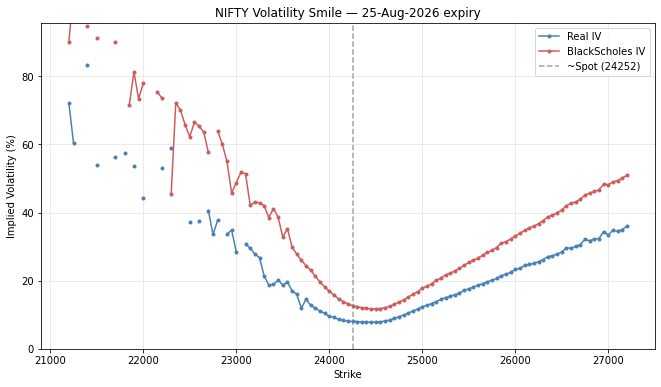

In [42]:
spot = 24252

plt.figure(figsize=(11, 6))
plt.plot(calls['StrikePrice'].to_numpy(), calls['IV'].to_numpy(), 'o-', ms=3, color='steelblue', label='Real IV')
plt.plot(calls['StrikePrice'].to_numpy(), calls['BSIv'].to_numpy(), 'o-', ms=3, color='indianred', label='BlackScholes IV')
plt.axvline(spot, ls='--', color='gray', alpha=.7, label=f'~Spot ({spot})')
plt.title('NIFTY Volatility Smile — 25-Aug-2026 expiry')
plt.xlabel('Strike'); plt.ylabel('Implied Volatility (%)')
plt.ylim(0, max(calls['IV'].max(), calls['IV'].max()) * 1.15)
plt.legend(); plt.grid(alpha=.3); plt.show()